# V3 moneyness performance — 1.5-year monthly study

**This notebook is the computational source of truth.** The matching PDF is written from the same payload.

This report classifies the **same** option contracts as `V3_1p5y_monthly_modified_gbm_empirical_study` into DOTM / OTM / ATM / ITM / DITM. It does not change filters, calibration, contracts, LSM settings, or the market benchmark.

| Item | Setting |
|------|---------|
| Models | GBM, GARCH, Heston, Merton, GARCH–Merton, Heston–Merton |
| Companies | SPY, AAPL, MSFT, AMZN (pooled in both analyses) |
| Regimes | Crisis, Normal, Late-cycle, COVID (pooled in Analysis 1; separate in Analysis 2) |
| Contracts | Monday nearest-ATM listed calls from the main study (`n = 802` per model) |
| Moneyness | `m = S/K` (calls) |
| Primary metric | RMSE% |
| Secondary | MAE, Bias $, **Bias%**, Early-exercise fraction |


## 0. Methodology

### Same design as the main study
1.5-year lookback, monthly recalibration, V3 filters (no-arbitrage, DTE 7–60, |S/K−1|≤10%, liquidity), Euler-corrected Heston, option-implied Heston NLS, LSM with 2,000 paths and seed 42. No look-ahead.

### Moneyness rule (calls)
Let `m = S/K`.

| Bucket | Rule |
|--------|------|
| DOTM | m < 0.98 |
| OTM | 0.98 ≤ m < 0.995 |
| ATM | 0.995 ≤ m ≤ 1.005 |
| ITM | 1.005 < m ≤ 1.02 |
| DITM | m > 1.02 |

These five bins partition the main-study 10% moneyness filter. The Monday ATM sampler concentrates mass in ATM.

### Metrics
- RMSE% = 100 × √ mean(((model − market)/market)²)
- Bias $ = mean(model − market)
- Bias% = 100 × mean((model − market)/market)
- BEST = lowest RMSE% among models with n > 0


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V3-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_1p5y_10k_monthly_modified_gbm as mx
panel = mx.load_panel()
payload = mx.build_payload(panel)
pdf = mx.write_pdf(payload)
print('n_overall', payload['n_overall'])
print('PDF', pdf)

## 1. Shared sample counts


In [1]:
display(HTML('counts'))

Regime,DOTM,OTM,ATM,ITM,DITM,Total
2008-2009,18,43,80,43,16,200
2013-2014,0,5,192,3,0,200
2018-2019,0,4,191,7,0,202
2019-2020,0,6,189,5,0,200
All,18,58,652,58,16,802


## 2. Analysis 1 — Overall moneyness


### Table M1. DOTM  ·  m < 0.98  ·  n = 18  ·  **BEST = Modified GBM**


In [1]:
tab = payload['analysis1']['DOTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
Modified GBM,18,43.64,1.0624,+0.2588,+18.53,21.5%,1


### Table M2. OTM  ·  0.98 ≤ m < 0.995  ·  n = 58  ·  **BEST = Modified GBM**


In [1]:
tab = payload['analysis1']['OTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
Modified GBM,58,58.42,1.5461,+0.6604,+29.31,22.6%,1


### Table M3. ATM  ·  0.995 ≤ m ≤ 1.005  ·  n = 652  ·  **BEST = Modified GBM**


In [1]:
tab = payload['analysis1']['ATM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
Modified GBM,652,46.30,5.4180,+2.9257,+27.92,24.6%,1


### Table M4. ITM  ·  1.005 < m ≤ 1.02  ·  n = 58  ·  **BEST = Modified GBM**


In [1]:
tab = payload['analysis1']['ITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
Modified GBM,58,36.00,1.3075,+0.2659,+10.23,27.4%,1


### Table M5. DITM  ·  m > 1.02  ·  n = 16  ·  **BEST = Modified GBM**


In [1]:
tab = payload['analysis1']['DITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
Modified GBM,16,31.39,1.1988,+0.1199,+10.29,28.3%,1


### Figure M1 — Model × Moneyness RMSE% heatmap


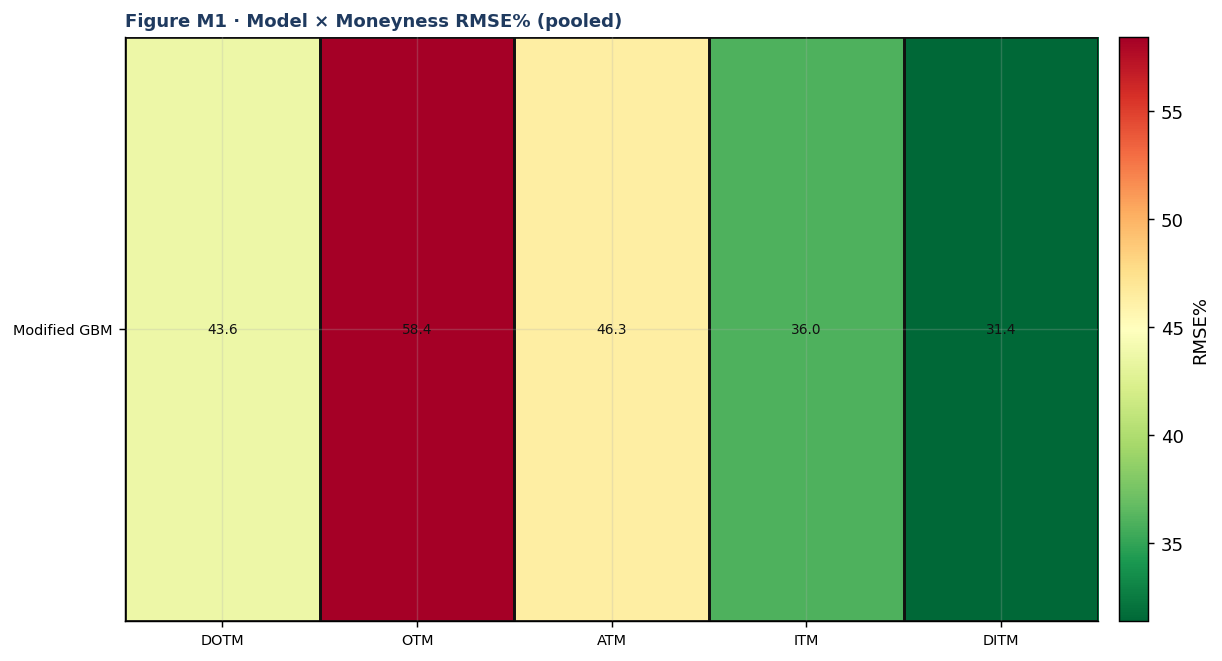

In [1]:
pass

## 3. Analysis 2 — Regime × moneyness


### Figure M2 — RMSE% heatmaps by regime


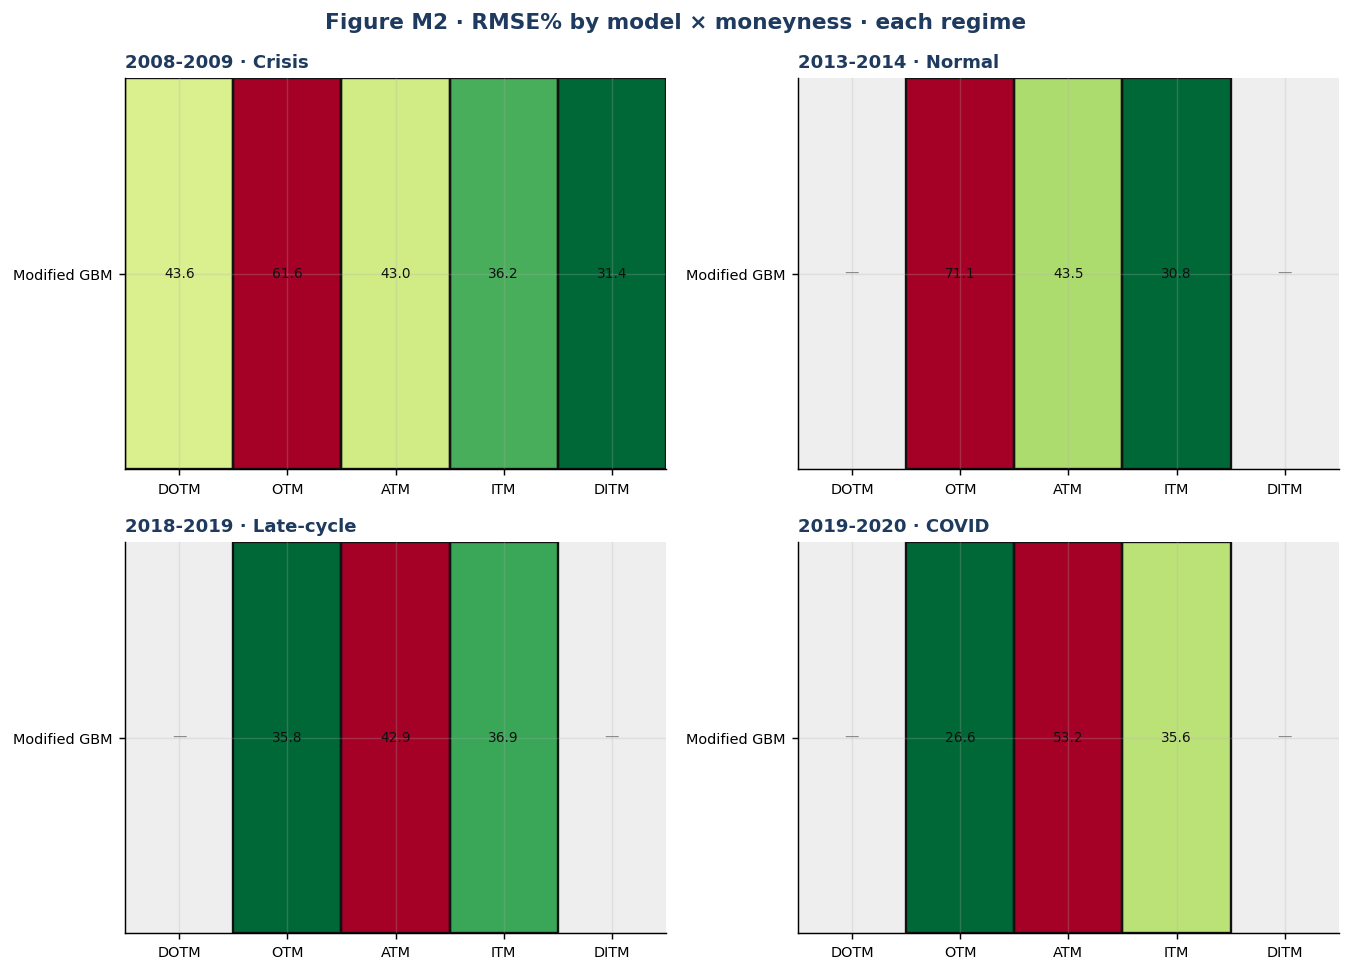

In [1]:
pass

### Table M6 — Best model by regime × moneyness


In [1]:
display(HTML('m6'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,Modified GBM,Modified GBM,Modified GBM,Modified GBM,Modified GBM
2013-2014,—,Modified GBM,Modified GBM,Modified GBM,—
2018-2019,—,Modified GBM,Modified GBM,Modified GBM,—
2019-2020,—,Modified GBM,Modified GBM,Modified GBM,—


### Table M7 — n by regime × moneyness


In [1]:
display(HTML('m7'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,18,43,80,43,16
2013-2014,0,5,192,3,0
2018-2019,0,4,191,7,0
2019-2020,0,6,189,5,0


## 4. Findings

- DOTM (n = 18): BEST = Modified GBM with RMSE% = 43.64, Bias% = +18.53.

- OTM (n = 58): BEST = Modified GBM with RMSE% = 58.42, Bias% = +29.31.

- ATM (n = 652): BEST = Modified GBM with RMSE% = 46.30, Bias% = +27.92.

- ITM (n = 58): BEST = Modified GBM with RMSE% = 36.00, Bias% = +10.23.

- DITM (n = 16): BEST = Modified GBM with RMSE% = 31.39, Bias% = +10.29.

- Overall, the moneyness ranking is stable: Modified GBM is BEST in every non-empty bucket.

- Inside each regime, the BEST model is the same in every non-empty moneyness bucket.

- These comparisons use the Monday nearest-ATM sample, so ATM is the only well-populated bucket after 2009. DOTM/DITM results rest on few 2008–2009 quotes and should be read as descriptive, not as a high-powered test.


## 5. Re-run

```python
import run_v3_1p5y_10k_monthly_modified_gbm as mx
payload = mx.run()
```

Requires the main study contract CSVs under `V3-Models_result/results/empirical_study_1p5y_monthly_10000_modified_gbm/contracts/`.
